# Dancing With The Stars: To The Top of the Leaderboard


# Introduction

Towards September through November, every Tuesday night at 8pm on ABC the popular television show Dancing with the Stars is shown. "Celebrities" like actors, athletes, comedians are paired with ballroom dancing "pros" where they perform chreographed dances live for the audience and once finished judges critique them and given a score 1-10. Additionally, viewers at home and in the audience vote for their favorite couple because at the end of each night one couple is eliminated until one couple is left and given the title as Mirrorball Champion. The question I want to explore is can I predict a celebrity's average dance score on Dancing with the Stars based on attributes such as their age, professional partner, industry background?

# The DataSet

The data set I chose is a file found from Kaggle: https://www.kaggle.com/datasets/brupley/dancing-with-the-stars-dataset?resource=download. It provides the competitors, scores, and results from seasons 1-32. 
    
    Personal attibutes include name, age during the season, home state/country, industry. 
    Competition details include professional dance partner, season number, final placement. 
    Performance data include weekly judges score from up to 11 weeks of competition. 
    Results include elimination status and final placement.


# Regrssion

Regressional is a statistical method used to model the relationship between a dependent variable (target) and one or more independent variables (features). Regarding the question I want to explore I'm using linear regression to predict weekly judges score on contestant attributes.

# Data Understanding

The information I examined that was available about each contestant including their age, profession, which season they competed in, and most importantly their weekly judges score the visualizations I can make is a scatter plot showing how age relates to scores. By looking at the scatterplot where the X-axis shows a contestant's age during the season and the y-axis shows their average dance score, there is a slight tendency for younger contestants to score higher. 

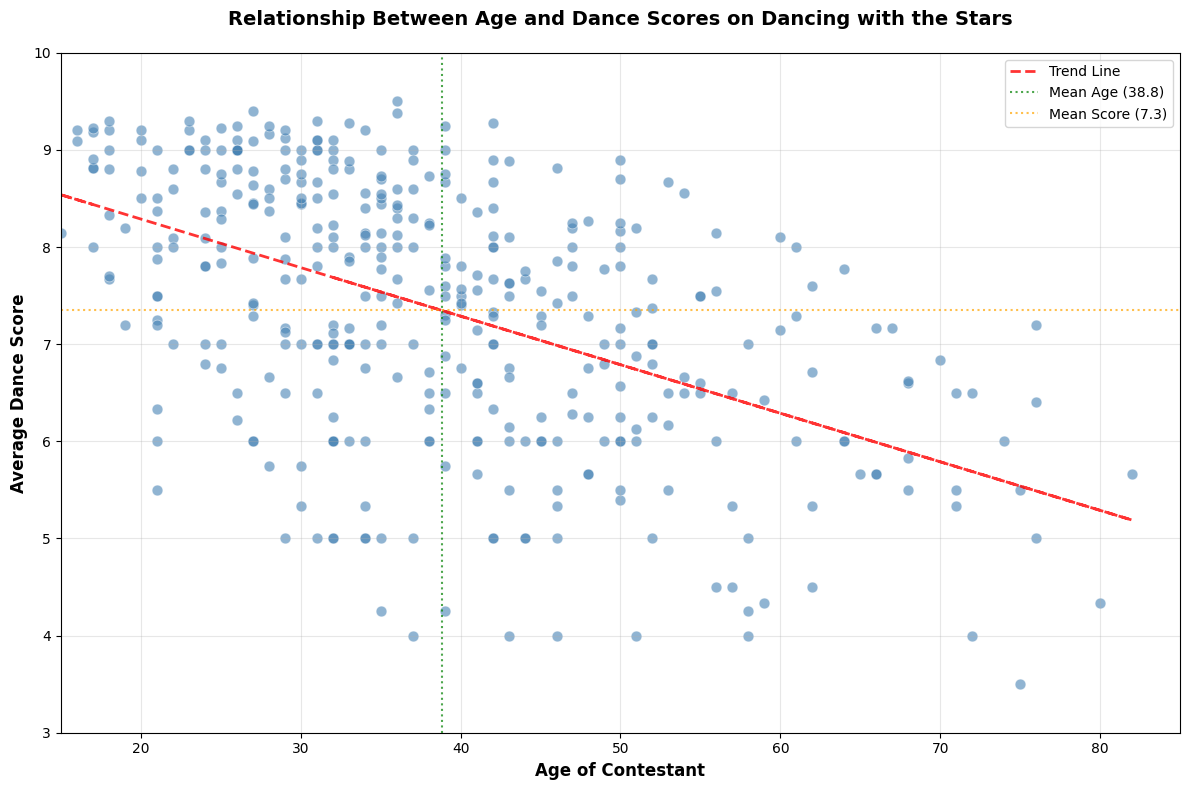

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and prepare the data
df = pd.read_csv("../datasets/dancing_with_the_stars_dataset.csv")

# Calculate average score for each contestant
score_columns = [col for col in df.columns if 'week' in col and 'score' in col and 'avg' in col]

def calculate_average_score(row):
    scores = []
    for col in score_columns:
        if pd.notna(row[col]) and row[col] > 0:
            scores.append(row[col])
    return np.mean(scores) if scores else np.nan

df['average_score'] = df.apply(calculate_average_score, axis=1)
df_clean = df.dropna(subset=['average_score', 'celebrity_age_during_season']).copy()

# Create the scatter plot
plt.figure(figsize=(12, 8))

# Create scatter plot with enhanced styling
plt.scatter(df_clean['celebrity_age_during_season'], df_clean['average_score'], 
           alpha=0.6, color='steelblue', s=60, edgecolor='white', linewidth=0.5)

# Add trend line
z = np.polyfit(df_clean['celebrity_age_during_season'], df_clean['average_score'], 1)
p = np.poly1d(z)
plt.plot(df_clean['celebrity_age_during_season'], p(df_clean['celebrity_age_during_season']), 
         "r--", alpha=0.8, linewidth=2, label='Trend Line')

# Customize the plot
plt.xlabel('Age of Contestant', fontsize=12, fontweight='bold')
plt.ylabel('Average Dance Score', fontsize=12, fontweight='bold')
plt.title('Relationship Between Age and Dance Scores on Dancing with the Stars', 
          fontsize=14, fontweight='bold', pad=20)

# Add grid and styling
plt.grid(True, alpha=0.3)
plt.xlim(15, 85)
plt.ylim(3, 10)


# Add some statistics
mean_age = df_clean['celebrity_age_during_season'].mean()
mean_score = df_clean['average_score'].mean()
plt.axvline(mean_age, color='green', linestyle=':', alpha=0.7, label=f'Mean Age ({mean_age:.1f})')
plt.axhline(mean_score, color='orange', linestyle=':', alpha=0.7, label=f'Mean Score ({mean_score:.1f})')

plt.legend()
plt.tight_layout()
plt.show()

